#  RETO 1 — PREDICCIÓN DEL APORTE MENSUAL DE EMPRESAS AFILIADAS
#### En este reto desarrollamos un modelo predictivo que ayudara a pronosticar el  aporte mensual esperado de cada empresa afiliada a Colsubsidio.
#### Con el objetivo de contar con estimaciones confiables para mejorar la planeacion financiera, priorizar acciones comerciales y comprender los factores que explican las diferencias en los aportes entre empresas afiliadas.

#### Metodología para generar la solucion final: CRISP-DM, luego comparar 4 modelos de regresion distintos, generar un algoritmo genetico para hacer un featuring selection adecuado y por ultimo SHAP values para interpretar el modelo final.

#### Para que la lectura del documento sea mas comoda, las funciones  para desarrollar el proceso viven en utils_r1.py.


In [1]:
import json
import sys
import warnings
from pathlib import Path
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

from utils_r1 import (RAIZ, RUTA_R1, SEMILLA, MedianaPorSector, cargar_r1, clonar, conformal_log, construir_modelos_r1,
                      cv_cop, elegir_ganador_1se, filtro_correlacion, ga_buscar_rapido, metricas_cop, particion_holdout,
                      preparar_r1, sha256_archivo, shap_arboles)


In [2]:
for ruta in [Path.cwd(), *Path.cwd().parents[:2], *[d for d in Path.cwd().glob("*") if d.is_dir()]]:
    if (ruta / "utils_r1.py").exists():
        sys.path.insert(0, str(ruta))
        break

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.2f}".format
print("[OK] Entorno y utilidades de Reto 1 listos. Semilla global =", SEMILLA)


[OK] Entorno y utilidades de Reto 1 listos. Semilla global = 42


# COMPRENSIÓN DEL NEGOCIO
#### - Pregunta: ¿cuánto aporta cada empresa afiliada al mes y qué factores se asocian con las diferencias?
#### - Uso: planeación financiera, priorización comercial y detección de aportes atípicos.
#### - Éxito: error típico bajo en pesos (MAE) y un modelo explicable. Los factores son ASOCIACIONES, no causas.

In [3]:
print("FASE 1: COMPRENSIÓN DEL NEGOCIO")
print("- Variable objetivo : aporte_mensual (COP por empresa y mes).")
print("- Métrica de decisión (fijada antes de modelar): MAE en COP; secundarias WAPE y MAPE.")
print("- Regla de selección : si dos modelos están a menos de 1 error estándar, gana el más simple.")
print("- Alcance            : se explican asociaciones; el diseño no permite afirmar causalidad.")


FASE 1: COMPRENSIÓN DEL NEGOCIO
- Variable objetivo : aporte_mensual (COP por empresa y mes).
- Métrica de decisión (fijada antes de modelar): MAE en COP; secundarias WAPE y MAPE.
- Regla de selección : si dos modelos están a menos de 1 error estándar, gana el más simple.
- Alcance            : se explican asociaciones; el diseño no permite afirmar causalidad.


# FASE 2 — AUDITORÍA DE CALIDAD DE DATOS (ANTES DE PREPARAR)
#### - Integridad (nulos, duplicados, tipos), categorías (escritura), rangos y valores en los límites, atípicos, reglas de coherencia.
#### - Señales a revisar y decisión de preparación documentada (qué se limpia y qué no, y por qué).
#### - Requiere haber ejecutado la celda 3 (usa df y ratio).

In [4]:
df = cargar_r1()
print(f"datos leídos de: {RUTA_R1}")
print(f"sha256 datos: {sha256_archivo(RUTA_R1)[:12]} | forma: {df.shape} | nulos: {int(df.isna().sum().sum())} | duplicados: {int(df.duplicated().sum())}")
print(f"ciudades: {df['ciudad'].nunique()} | sectores: {df['sector'].nunique()} | id_empresa único: {df['id_empresa'].is_unique}")


aporte = df["aporte_mensual"]
skew_bruto, skew_log = float(aporte.skew()), float(np.log(aporte).skew())
corr_trab = float(aporte.corr(df["numero_trabajadores"]))
ratio = aporte / (df["numero_trabajadores"] * df["salario_promedio"])


datos leídos de: D:\2026_2\colsubsidio\Jupyter_notebooks\problema_1\empresas_afiliadas.csv
sha256 datos: 5c6e854de33f | forma: (10000, 16) | nulos: 0 | duplicados: 0
ciudades: 9 | sectores: 12 | id_empresa único: True


In [5]:
num_cols = [c for c in df.columns if c not in ("id_empresa", "ciudad", "sector")]

print("1) INTEGRIDAD")
print(f"   nulos: {int(df.isna().sum().sum())} | duplicados exactos: {int(df.duplicated().sum())} | duplicados ignorando id: {int(df.drop(columns='id_empresa').duplicated().sum())}")
print(f"   tipos: {df.dtypes.astype(str).value_counts().to_dict()}")
print("\n2) CATEGORÍAS (espacios, mayúsculas/minúsculas, número de valores)")



1) INTEGRIDAD
   nulos: 0 | duplicados exactos: 0 | duplicados ignorando id: 0
   tipos: {'float64': 11, 'int64': 3, 'str': 2}

2) CATEGORÍAS (espacios, mayúsculas/minúsculas, número de valores)


In [6]:
for c in ("ciudad", "sector"):
    s = df[c]
    print(f"   {c}: {s.nunique()} valores | espacios sobrantes: {int((s != s.str.strip()).sum())} | variantes de escritura: {s.nunique() - s.str.lower().str.strip().nunique()}")
print(f"   'Otras' agrupa {int((df['ciudad'] == 'Otras').sum())} empresas (categoría residual: no se puede desagregar)")

print("\n3) RANGOS, VALORES EN LOS LÍMITES Y ATÍPICOS (regla 1.5 x IQR)")


   ciudad: 9 valores | espacios sobrantes: 0 | variantes de escritura: 0
   sector: 12 valores | espacios sobrantes: 0 | variantes de escritura: 0
   'Otras' agrupa 501 empresas (categoría residual: no se puede desagregar)

3) RANGOS, VALORES EN LOS LÍMITES Y ATÍPICOS (regla 1.5 x IQR)


In [7]:
filas = []
for c in num_cols:
    s = df[c]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_at = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
    filas.append(dict(variable=c, minimo=s.min(), maximo=s.max(), n_en_minimo=int((s == s.min()).sum()),
                      n_en_maximo=int((s == s.max()).sum()), atipicos_iqr=n_at, pct_atipicos=round(100 * n_at / len(s), 1)))
tabla_calidad = pd.DataFrame(filas).set_index("variable")
print(tabla_calidad.to_string(float_format=lambda v: f"{v:,.2f}"))

print("\n4) REGLAS DE COHERENCIA (deben cumplirse)")


                            minimo        maximo  n_en_minimo  n_en_maximo  atipicos_iqr  pct_atipicos
variable                                                                                              
antiguedad_empresa            1.00         60.00           15           92           568          5.70
distancia_centro              0.00         80.00            1            1             0          0.00
productividad                17.60         95.00            1            7            53          0.50
numero_trabajadores           1.00        353.00          199            1           776          7.80
salario_promedio              1.50          7.07            4            1            45          0.50
rotacion_personal             0.00         45.60           53            1             2          0.00
crecimiento_nomina          -15.00         29.10            2            1            97          1.00
numero_servicios              0.00         10.00         2894            

In [8]:
reglas = {
    "aporte_mensual > 0": (df["aporte_mensual"] > 0).all(),
    "numero_trabajadores >= 1": (df["numero_trabajadores"] >= 1).all(),
    "salario_promedio > 0": (df["salario_promedio"] > 0).all(),
    "índices y productividad dentro de [0, 100]": df[["productividad", "indice_formalizacion", "indice_digitalizacion", "indice_competencia"]].apply(lambda s: s.between(0, 100).all()).all(),
    "antiguedad_empresa >= 0, distancia_centro >= 0, rotacion_personal >= 0": ((df["antiguedad_empresa"] >= 0) & (df["distancia_centro"] >= 0) & (df["rotacion_personal"] >= 0)).all(),
}
for nombre, ok in reglas.items():
    print(f"   {'OK   ' if ok else 'FALLA'} {nombre}")

print("\n5) SEÑALES A REVISAR (no son errores comprobados)")


   OK    aporte_mensual > 0
   OK    numero_trabajadores >= 1
   OK    salario_promedio > 0
   OK    índices y productividad dentro de [0, 100]
   OK    antiguedad_empresa >= 0, distancia_centro >= 0, rotacion_personal >= 0

5) SEÑALES A REVISAR (no son errores comprobados)


In [9]:
for c in num_cols:
    if tabla_calidad.loc[c, "n_en_maximo"] >= 30:
        print(f"   - {c}: {int(tabla_calidad.loc[c, 'n_en_maximo'])} empresas valen exactamente el máximo ({tabla_calidad.loc[c, 'maximo']:,.0f}): posible tope o recorte en el origen (NO_DETERMINADO con estos datos)")
top1 = df[df["aporte_mensual"] > df["aporte_mensual"].quantile(0.99)]
print(f"   - Los {len(top1)} aportes por encima del P99 vienen de empresas grandes (mediana {top1['numero_trabajadores'].median():.0f} trabajadores vs {df['numero_trabajadores'].median():.0f} en toda la base): se consideran plausibles.")
print(f"   - Aporte superior a la nómina estimada (trabajadores x salario) en {int((ratio > 1).sum())} empresas ({(ratio > 1).mean():.1%}); razón media {ratio.mean():.2f}: no se puede verificar si la base es real o sintética (NO_DETERMINADO).")
corr_pred = df[num_cols].drop(columns="aporte_mensual").corr().abs()
pares = corr_pred.where(np.triu(np.ones(corr_pred.shape), 1).astype(bool)).stack().sort_values(ascending=False)
print(f"   - Mayor correlación entre predictores: {pares.index[0][0]} vs {pares.index[0][1]} = {pares.iloc[0]:.2f} (sin multicolinealidad severa).")



   - antiguedad_empresa: 92 empresas valen exactamente el máximo (60): posible tope o recorte en el origen (NO_DETERMINADO con estos datos)
   - Los 100 aportes por encima del P99 vienen de empresas grandes (mediana 144 trabajadores vs 14 en toda la base): se consideran plausibles.
   - Aporte superior a la nómina estimada (trabajadores x salario) en 10000 empresas (100.0%); razón media 267726.69: no se puede verificar si la base es real o sintética (NO_DETERMINADO).
   - Mayor correlación entre predictores: productividad vs salario_promedio = 0.62 (sin multicolinealidad severa).


# DECISION PREPARACION DATAFRAME:
#### No se eliminan ni imputan filas: hay 0 nulos, 0 duplicados y todas las reglas de coherencia se cumplen.
#### Los atípicos se conservan (corresponden a empresas grandes); limitación: no se midió el efecto de excluirlos.
####  Se trabaja el objetivo en escala log para la cola derecha (ver asimetría arriba).


# FASE 2B — COMPRENSIÓN DE LOS DATOS
#### - Hash del archivo original, dimensiones, nulos, duplicados.
#### - Distribución y asimetría del aporte; relación con el número de trabajadores.

sha256 datos: 5c6e854de33f | forma: (10000, 16) | nulos: 0 | duplicados: 0
ciudades: 9 | sectores: 12 | id_empresa único: True

Aporte mensual (COP):
count        10,000
mean     10,525,344
std       4,895,193
min       3,277,921
25%       7,634,422
50%       9,331,664
75%      11,869,411
max      76,547,713

Asimetría: 3.301 en bruto -> 0.862 con log
Correlación aporte vs numero_trabajadores: 0.8921
Razón aporte/(trabajadores x salario): mín 0.0448 | media 0.2677 | máx 3.7070  -> no es una proporción fija


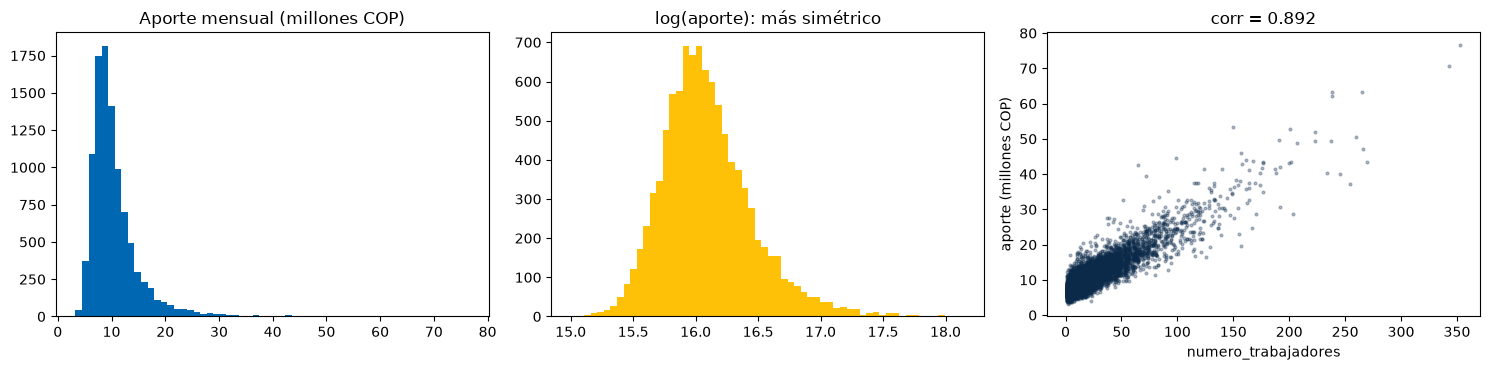

In [10]:
df = cargar_r1()
print(f"sha256 datos: {sha256_archivo(RUTA_R1)[:12]} | forma: {df.shape} | nulos: {int(df.isna().sum().sum())} | duplicados: {int(df.duplicated().sum())}")
print(f"ciudades: {df['ciudad'].nunique()} | sectores: {df['sector'].nunique()} | id_empresa único: {df['id_empresa'].is_unique}")

aporte = df["aporte_mensual"]
print("\nAporte mensual (COP):")
print(aporte.describe().apply(lambda v: f"{v:,.0f}").to_string())

skew_bruto, skew_log = float(aporte.skew()), float(np.log(aporte).skew())
corr_trab = float(aporte.corr(df["numero_trabajadores"]))
ratio = aporte / (df["numero_trabajadores"] * df["salario_promedio"] * 1e6)  # salario_promedio está en millones de COP
print(f"\nAsimetría: {skew_bruto:.3f} en bruto -> {skew_log:.3f} con log")
print(f"Correlación aporte vs numero_trabajadores: {corr_trab:.4f}")
print(f"Razón aporte/(trabajadores x salario): mín {ratio.min():.4f} | media {ratio.mean():.4f} | máx {ratio.max():.4f}  -> no es una proporción fija")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(aporte / 1e6, bins=60, color="#0068B3"); ax[0].set_title("Aporte mensual (millones COP)")
ax[1].hist(np.log(aporte), bins=60, color="#FFC107"); ax[1].set_title("log(aporte): más simétrico")
ax[2].scatter(df["numero_trabajadores"], aporte / 1e6, s=4, alpha=0.3, color="#0B2A4A")
ax[2].set_xlabel("numero_trabajadores"); ax[2].set_ylabel("aporte (millones COP)"); ax[2].set_title(f"corr = {corr_trab:.3f}")
plt.tight_layout(); plt.show()

# FASE 3 — PREPARACIÓN DE LOS DATOS Y PARTICIÓN
#### - id_empresa fuera (identificador). ciudad (9) y sector (12): one-hot (baja cardinalidad, sin riesgo de fuga).
#### - Objetivo en escala log; las métricas se reportan en COP tras exp().
#### - 20 % hold-out intacto (random_state=42); del 80 % restante, 25 % de calibración solo para los intervalos conformal.

In [11]:
X, y_log, grupos = preparar_r1(df)
idx_tr, idx_te = particion_holdout(len(df))
X_tr, y_tr, X_te, y_te = X.iloc[idx_tr], y_log[idx_tr], X.iloc[idx_te], y_log[idx_te]
perm = np.random.default_rng(SEMILLA).permutation(len(idx_tr))
idx_cal, idx_pr = perm[: len(perm) // 4], perm[len(perm) // 4:]
print(f"columnas tras one-hot: {X.shape[1]} | variables originales (genes): {len(grupos)}")
print(f"train: {X_tr.shape} | hold-out: {X_te.shape} | calibración conformal: {len(idx_cal)} | ajuste conformal: {len(idx_pr)}")


columnas tras one-hot: 33 | variables originales (genes): 14
train: (8000, 33) | hold-out: (2000, 33) | calibración conformal: 2000 | ajuste conformal: 6000


In [12]:
X.head(10)

,antiguedad_empresa,distancia_centro,productividad,numero_trabajadores,salario_promedio,rotacion_personal,crecimiento_nomina,numero_servicios,indice_formalizacion,indice_digitalizacion,...,sector_Construcción,sector_Energía,sector_Financiero,sector_Hoteles,sector_Información,sector_Manufactura,sector_Minas,sector_Profesionales,sector_Salud,sector_Transporte
0,9.80,52.25,48.10,2,3.53,24.20,-5.40,1,74.30,62.30,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
1,17.50,58.81,54.20,29,4.09,23.10,2.70,1,60.60,71.50,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,7.30,71.78,88.70,3,4.87,13.60,0.50,1,80.20,64.20,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
3,3.40,50.57,65.70,3,4.77,11.70,5.60,1,69.30,66.80,...,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,22.00,4.93,66.70,5,4.87,6.50,0.90,0,73.70,71.20,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,18.50,44.81,49.90,11,2.88,31.50,5.70,0,59.10,54.30,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,28.70,52.21,63.20,21,3.26,20.40,10.00,2,78.90,75.70,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
7,6.20,66.18,52.70,5,3.20,9.70,7.40,2,62.20,59.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
8,12.60,73.23,62.20,11,3.52,23.00,14.70,2,75.40,59.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,18.80,76.46,47.70,20,3.56,17.80,10.10,3,64.00,52.40,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


# FASE 4 — MODELADO: 6 MODELOS COMPARADOS (CV 5 folds x 2 repeticiones, solo sobre el train)
#### - Baselines: mediana por sector y OLS(log). Modelos: Ridge, Random Forest, XGBoost, LightGBM (todos sobre log).
#### - Hiperparámetros fijados a priori (no se afinan con el hold-out). Selección por regla 1-SE.

MAE de validación cruzada (COP), de mejor a peor:
                      mae_media    mae_se
XGBoost(log)         429,261.00  5,525.00
LightGBM(log)        442,119.00  5,937.00
RandomForest(log)    586,473.00  5,416.00
Ridge(log)           991,042.00 31,935.00
OLS(log)             992,490.00 32,220.00
Mediana por sector 2,722,856.00 18,162.00

Mejor por MAE: XGBoost(log) | ganador con regla 1-SE: XGBoost(log)


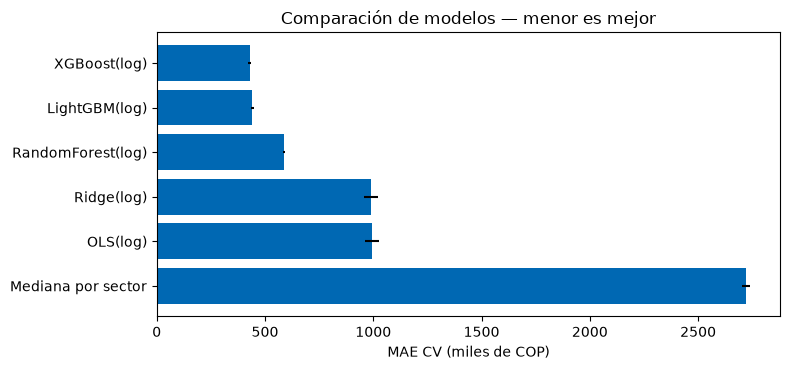

In [13]:
modelos = construir_modelos_r1()
sector_cols = [c for c in X.columns if c.startswith("sector_")]
modelos_cv = {"Mediana por sector": MedianaPorSector(sector_cols), "OLS(log)": LinearRegression(), **modelos}
tabla = {nombre: cv_cop(m, X_tr, y_tr) for nombre, m in modelos_cv.items()}
res = pd.DataFrame(tabla).T[["mae_media", "mae_se"]].sort_values("mae_media")
print("MAE de validación cruzada (COP), de mejor a peor:")
print(res.round(0).to_string())

modelos_ml = ["Ridge(log)", "RandomForest(log)", "XGBoost(log)", "LightGBM(log)"]
orden_simpleza = ["Ridge(log)", "RandomForest(log)", "LightGBM(log)", "XGBoost(log)"]
ganador, mejor = elegir_ganador_1se({k: tabla[k] for k in modelos_ml}, orden_simpleza)
print(f"\nMejor por MAE: {mejor} | ganador con regla 1-SE: {ganador}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(res.index[::-1], res["mae_media"][::-1] / 1e3, xerr=res["mae_se"][::-1] / 1e3, color="#0068B3")
ax.set_xlabel("MAE CV (miles de COP)"); ax.set_title("Comparación de modelos — menor es mejor")
plt.tight_layout(); plt.show()

# FASE 4 — CONTRASTE: ¿ENTRENAR EN LOG O DIRECTO?
#### - Mismo Xgboost en ambas escalas (5 folds), para justificar la elección del objetivo log.

In [14]:
y_dir = np.exp(y_tr)
maes_dir, maes_log, r2_dir, r2_log_cv = [], [], [], []
for tr, va in KFold(5, shuffle=True, random_state=SEMILLA).split(X_tr):
    m_dir = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                             objective="reg:absoluteerror", random_state=SEMILLA, n_jobs=8, tree_method="hist", verbosity=0)
    m_dir.fit(X_tr.iloc[tr], y_dir[tr])
    pred_dir = m_dir.predict(X_tr.iloc[va])
    maes_dir.append(np.mean(np.abs(pred_dir - y_dir[va])))
    r2_dir.append(r2_score(y_dir[va], pred_dir))
    m_log = clonar(modelos["XGBoost(log)"]).fit(X_tr.iloc[tr], y_tr[tr])
    pred_log = m_log.predict(X_tr.iloc[va])
    maes_log.append(metricas_cop(y_tr[va], pred_log)["mae"])
    r2_log_cv.append(r2_score(y_dir[va], np.exp(pred_log)))   # R² en pesos, comparable con el del objetivo directo

mae_dir, mae_log = float(np.mean(maes_dir)), float(np.mean(maes_log))
dif = np.array(maes_dir) - np.array(maes_log)            # negativo = el directo comete menos error
dif_media, se_par = float(dif.mean()), float(dif.std(ddof=1) / np.sqrt(len(dif)))
tabla_escala = pd.DataFrame({"MAE CV (COP)": [mae_dir, mae_log], "R² CV (en pesos)": [np.mean(r2_dir), np.mean(r2_log_cv)]},
                            index=["Objetivo directo (error absoluto)", "Objetivo en log"])
print(tabla_escala.to_string(formatters={"MAE CV (COP)": "{:,.0f}".format, "R² CV (en pesos)": "{:.1%}".format}))
print(f"Diferencia media (directo - log): {dif_media:,.0f} COP ({dif_media / mae_log:+.1%}) | error estándar pareado {se_par:,.0f} | el directo gana en {(dif < 0).sum()} de {len(dif)} folds")
if abs(dif_media) <= se_par:
    print("Lectura: empate técnico; se mantiene el log por interpretabilidad.")
elif dif_media < 0:
    print(f"Lectura: el objetivo directo rinde mejor por {abs(dif_media) / se_par:.0f} errores estándar. Se mantiene el log por interpretabilidad "
          f"(efectos en %, rangos multiplicativos), aceptando un costo de ~{abs(dif_media):,.0f} COP de error.")
else:
    print("Lectura: el log rinde mejor; se mantiene.")
dif_r2 = float(np.mean(r2_dir) - np.mean(r2_log_cv))
if (dif_media < 0) == (dif_r2 < 0):   # las dos métricas se contradicen (dif_media < 0: el directo gana en error; dif_r2 < 0: el directo pierde en R²)
    print(f"Matiz: el error absoluto favorece al {'objetivo directo' if dif_media < 0 else 'log'}, pero el R² favorece al {'log' if dif_r2 < 0 else 'objetivo directo'} "
          f"({np.mean(r2_log_cv):.1%} vs {np.mean(r2_dir):.1%}): el R² castiga más los errores grandes, que ocurren en las empresas más grandes; la elección depende de qué error importa más al negocio.")


                                  MAE CV (COP) R² CV (en pesos)
Objetivo directo (error absoluto)      412,754            95.4%
Objetivo en log                        427,239            96.0%
Diferencia media (directo - log): -14,485 COP (-3.4%) | error estándar pareado 1,295 | el directo gana en 5 de 5 folds
Lectura: el objetivo directo rinde mejor por 11 errores estándar. Se mantiene el log por interpretabilidad (efectos en %, rangos multiplicativos), aceptando un costo de ~14,485 COP de error.
Matiz: el error absoluto favorece al objetivo directo, pero el R² favorece al log (96.0% vs 95.4%): el R² castiga más los errores grandes, que ocurren en las empresas más grandes; la elección depende de qué error importa más al negocio.


#  FASE 4b — SELECCIÓN DE VARIABLES CON ALGORITMO GENÉTICO (PARSIMONIA)
#### - Cromosoma = 14 variables originales (ciudad y sector agrupan sus dummies).
#### - Fitness a minimizar = MAE_CV (millones COP) + lambda x nº de variables, lambda = 0.01. Solo usa el TRAIN.
#### - Población 20, 12 generaciones, torneo 3, cruce uniforme, mutación 12 %, elitismo 2, 5 semillas para medir estabilidad.
#### - Rápido porque: (1) el modelo del fitness es XGBoost determinista (sin muestreo aleatorio, 1 hilo por ajuste), así el resultado
####   de un subconjunto no depende del número de hilos; (2) los individuos nuevos de cada generación se evalúan en paralelo (8 hilos);
#### - Dataframe con variables transformadas pasa de 14 a 33.

semilla 42: 9 variables | fitness 0.6023 -> 0.5499 | 203 s acumulados
semilla 1: 8 variables | fitness 0.6023 -> 0.5466 | 392 s acumulados
semilla 2: 8 variables | fitness 0.6023 -> 0.5466 | 563 s acumulados
semilla 3: 8 variables | fitness 0.6023 -> 0.5466 | 711 s acumulados
semilla 4: 8 variables | fitness 0.6023 -> 0.5561 | 843 s acumulados

Frecuencia de selección por variable (fracción de las 5 semillas):
antiguedad_empresa      1.00
productividad           1.00
salario_promedio        1.00
numero_trabajadores     1.00
numero_servicios        1.00
crecimiento_nomina      1.00
indice_formalizacion    1.00
indice_digitalizacion   1.00
rotacion_personal       0.20
distancia_centro        0.00
indice_competencia      0.00
satisfaccion_servicio   0.00
ciudad                  0.00
sector                  0.00

Variables estables elegidas por el GA (en >= 60% de las semillas): ['antiguedad_empresa', 'productividad', 'numero_trabajadores', 'salario_promedio', 'crecimiento_nomina', 'numero

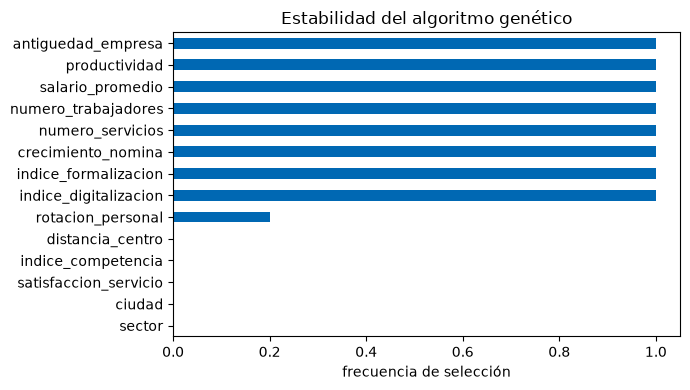

In [15]:
lam = 0.01
base_ga = clonar(modelos["XGBoost(log)"]).set_params(n_estimators=120, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0, n_jobs=1)
frecuencia = pd.Series(0.0, index=list(grupos))
subconjuntos, cache = {}, {}
t0 = time.time()
for semilla in [42, 1, 2, 3, 4]:
    sel, hist, cache = ga_buscar_rapido(grupos, X_tr, y_tr, base_ga, lam, semilla, cache=cache, n_jobs=8, paciencia=None)
    subconjuntos[semilla] = sel
    frecuencia[sel] += 1 / 5
    print(f"semilla {semilla}: {len(sel)} variables | fitness {hist[0]:.4f} -> {hist[-1]:.4f} | {time.time() - t0:.0f} s acumulados")
frecuencia = frecuencia.sort_values(ascending=False)
print("\nFrecuencia de selección por variable (fracción de las 5 semillas):")
print(frecuencia.to_string())
UMBRAL_ESTABLE = 0.6
genes_ga = [g for g in grupos if frecuencia[g] >= UMBRAL_ESTABLE]  
cols_ga = [c for g in genes_ga for c in grupos[g]]
print(f"\nVariables estables elegidas por el GA (en >= {UMBRAL_ESTABLE:.0%} de las semillas): {genes_ga}")

fig, ax = plt.subplots(figsize=(7, 4))
frecuencia[::-1].plot.barh(ax=ax, color="#0068B3"); ax.set_xlabel("frecuencia de selección"); ax.set_title("Estabilidad del algoritmo genético")
plt.tight_layout(); plt.show()


#### Segun el algoritmo genetico, las variables que generan valor al modelo son:

#### -  'antiguedad_empresa'
#### - 'productividad'
#### - 'numero_trabajadores' 
#### -'salario_promedio'
#### - 'crecimiento_nomina'
#### -'numero_servicios'
#### - 'indice_formalizacion'
#### -'indice_digitalizacion'

#  FASE 4b — ¿EL MODELO PARSIMONIOSO RINDE IGUAL?
#### - Se compara: modelo completo vs variables del GA vs filtro simple de correlación con el mismo número de variables.
#### - Criterio: el GA se adopta solo si su MAE CV queda dentro de 1 error estándar del completo.

In [16]:
modelo_ganador = modelos[ganador]
genes_filtro = filtro_correlacion(X_tr, y_tr, grupos, k=len(genes_ga))
cols_filtro = [c for g in genes_filtro for c in grupos[g]]
conjuntos = {"Completo": list(X.columns), "GA (variables estables)": cols_ga, "Filtro correlación (mismo k)": cols_filtro}
comp = {}
for nombre, cols in conjuntos.items():
    cv = cv_cop(modelo_ganador, X_tr, y_tr, columnas=cols)
    m = clonar(modelo_ganador).fit(X_tr[cols], y_tr)
    ho_c = metricas_cop(y_te, m.predict(X_te[cols]))
    comp[nombre] = dict(variables=len(cols), cv_mae=cv["mae_media"],
                        cv_se=cv["mae_se"], holdout_mae=ho_c["mae"], holdout_wape=ho_c["wape"])
tab_ga = pd.DataFrame(comp).T
print(tab_ga.round(1).to_string())
print("Nota: 'variables' = columnas que recibe el modelo. ciudad se abre en 9 columnas y sector en 12 (variables dummy), por eso el modelo completo trabaja con 33 variables.")
umbral = comp["Completo"]["cv_mae"] + comp["Completo"]["cv_se"]
usa_ga = comp["GA (variables estables)"]["cv_mae"] <= umbral
print(f"\nUmbral 1-SE del completo: {umbral:,.0f} | MAE CV del GA: {comp['GA (variables estables)']['cv_mae']:,.0f} -> ¿se adopta el GA?: {usa_ga}")
print(f"Filtro simple con las mismas variables: MAE CV {comp['Filtro correlación (mismo k)']['cv_mae']:,.0f} (mucho peor que el GA)")
cols_final = cols_ga if usa_ga else list(X.columns)
print(f"Modelo final: {ganador} con {len(cols_final)} columnas ({'parsimonioso GA' if usa_ga else 'todas las variables'})")



                              variables     cv_mae    cv_se  holdout_mae  holdout_wape
Completo                          33.00 429,261.50 5,525.30   432,254.40          4.10
GA (variables estables)            8.00 434,971.70 5,805.00   448,002.50          4.20
Filtro correlación (mismo k)      19.00 533,804.40 7,430.70   544,941.10          5.10
Nota: 'variables' = columnas que recibe el modelo. ciudad se abre en 9 columnas y sector en 12 (variables dummy), por eso el modelo completo trabaja con 33 variables.

Umbral 1-SE del completo: 434,787 | MAE CV del GA: 434,972 -> ¿se adopta el GA?: False
Filtro simple con las mismas variables: MAE CV 533,804 (mucho peor que el GA)
Modelo final: XGBoost(log) con 33 columnas (todas las variables)


# LA PRUEBA FINAL: ¿QUÉ TAN BIEN PREDICE EL MODELO CON EMPRESAS NUEVAS?
#### - Al comienzo separamos 2,000 empresas (20 %) y NO las usamos para elegir ni ajustar nada: son el "examen final".
#### - Aquí medimos el error típico que tendría el modelo con empresas que nunca vio. Es la cifra honesta que se reporta.
#### - Además damos, para cada predicción, un RANGO ESPERADO: un intervalo donde el aporte real debería caer unas 8 de cada 10 veces.

EXAMEN FINAL (2,000 empresas que el modelo nunca vio)
- Error típico (MAE): 432,254 COP por empresa, es decir el 4.1% del aporte medio.
- Error porcentual medio por empresa (MAPE): 3.81% | error total sobre el aporte total (WAPE): 4.05%
- R² (qué parte de las diferencias de aporte entre empresas explica el modelo): 96.3% en pesos | 96.0% en escala log

RANGO ESPERADO DE CADA PREDICCIÓN (nivel 80 %)
- Regla: el aporte real debería estar entre la predicción x0.950 y la predicción x1.053.
- Ejemplo: si el modelo predice 10,000,000 COP, el rango esperado es de 9,499,137 a 10,527,272 COP.
- En el examen final, el aporte real cayó dentro de su rango en el 79.7% de las empresas (objetivo: 80%).


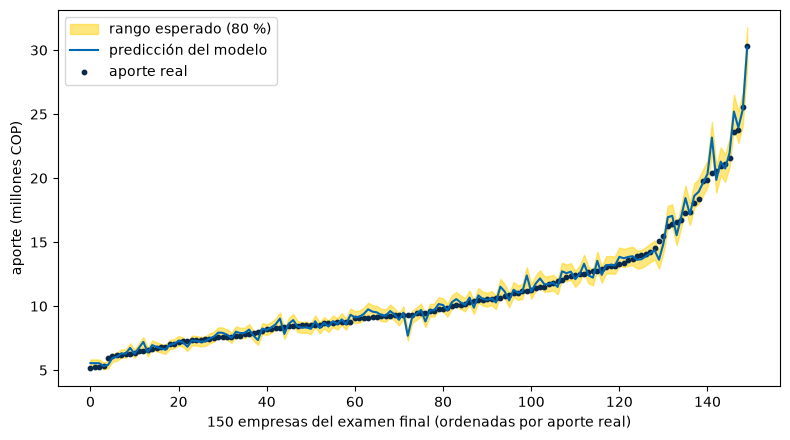

In [17]:
final = clonar(modelo_ganador).fit(X_tr[cols_final], y_tr)   # modelo ganador, ajustado solo con el train
pred_te = final.predict(X_te[cols_final])                     # predicción para las 2,000 empresas del examen final
ho = metricas_cop(y_te, pred_te)
real, pred_cop = np.exp(y_te), np.exp(pred_te)

print("EXAMEN FINAL (2,000 empresas que el modelo nunca vio)")
print(f"- Error típico (MAE): {ho['mae']:,.0f} COP por empresa, es decir el {ho['mae'] / aporte.mean():.1%} del aporte medio.")
print(f"- Error porcentual medio por empresa (MAPE): {ho['mape']:.2f}% | error total sobre el aporte total (WAPE): {ho['wape']:.2f}%")
r2_cop, r2_log = r2_score(real, pred_cop), r2_score(y_te, pred_te)
print(f"- R² (qué parte de las diferencias de aporte entre empresas explica el modelo): {r2_cop:.1%} en pesos | {r2_log:.1%} en escala log")

cf = conformal_log(modelo_ganador, X_tr.iloc[idx_pr][cols_final], y_tr[idx_pr], X_tr.iloc[idx_cal][cols_final], y_tr[idx_cal],
                   X_te[cols_final], y_te, nivel=0.8)
print("\nRANGO ESPERADO DE CADA PREDICCIÓN (nivel 80 %)")
print(f"- Regla: el aporte real debería estar entre la predicción x{cf['factor_inf']:.3f} y la predicción x{cf['factor_sup']:.3f}.")
print(f"- Ejemplo: si el modelo predice 10,000,000 COP, el rango esperado es de {10e6 * cf['factor_inf']:,.0f} a {10e6 * cf['factor_sup']:,.0f} COP.")
print(f"- En el examen final, el aporte real cayó dentro de su rango en el {cf['cobertura']:.1f}% de las empresas (objetivo: 80%).")

muestra = np.random.default_rng(SEMILLA).choice(len(real), 150, replace=False)
muestra = muestra[np.argsort(real[muestra])]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(range(len(muestra)), pred_cop[muestra] * cf["factor_inf"] / 1e6, pred_cop[muestra] * cf["factor_sup"] / 1e6,
                color="#FFD100", alpha=0.5, label="rango esperado (80 %)")
ax.plot(range(len(muestra)), pred_cop[muestra] / 1e6, color="#0068B3", label="predicción del modelo")
ax.scatter(range(len(muestra)), real[muestra] / 1e6, s=10, color="#0B2A4A", label="aporte real")
ax.set_xlabel("150 empresas del examen final (ordenadas por aporte real)"); ax.set_ylabel("aporte (millones COP)"); ax.legend()
plt.tight_layout(); plt.show()

#### Conclusión final: Con 2.000 empresas que el modelo nunca vio, el error promedio al estimar el aporte mensual de una empresa nueva es de 432.254 COP, un 4,1 % de su aporte medio. Es un buen resultado: reduce el error en un 84 % frente a una estimación simple por sector (según la validación cruzada). Además, cada estimación puede acompañarse de un rango esperado de aproximadamente -5 % a +5 %, dentro del cual cayó el aporte real en el 79,7 % de las empresas (unas 8 de cada 10), tal como se esperaba. En resumen, el modelo permite anticipar el aporte de cada empresa con un margen cercano al 4 % y un rango confiable para negociar y detectar aportes atípicos.


# FASE 5b — INTERPRETABILIDAD (1/3): ¿QUÉ VARIABLES PESAN MÁS EN EL APORTE?
#### - La importancia nativa de los árboles (gain) tiene sesgos conocidos; por eso se usa SHAP, que descompone la predicción de cada
####   empresa en la contribución de cada variable y cuya suma cuadra exactamente con la predicción (se verifica abajo).
#### - La importancia se agrupa por variable original (ciudad y sector suman sus dummies) y se clasifica por tipo de variable.
#### - Es asociación, no causalidad. La clasificación por tipo es un SUPUESTO de negocio, no sale de los datos.

Modelo que se explica: XGBoost(log) con 8 variables (parsimonioso). Error en el examen final: 448,002 COP frente a 432,254 COP del modelo completo (+3.6%).
R² del modelo parsimonioso: 96.3% en pesos | 95.9% en escala log (modelo completo: 96.3% | 96.0%).
Aditividad SHAP: error máximo |base + suma(SHAP) - predicción| = 3.24e-05 (escala log)  -> cumple (< 1e-4)

Ranking de importancia (mayor a menor). SHAP = peso medio de la variable en la predicción; Gain = importancia nativa del árbol:
                              Tipo  SHAP (%)  Gain nativo (%)
numero_trabajadores    Estructural     46.30            61.90
productividad            Operativa     15.90            16.70
salario_promedio       Estructural     10.40             5.70
indice_formalizacion       Palanca      8.90             6.10
numero_servicios           Palanca      6.80             6.00
crecimiento_nomina       Operativa      5.70             1.30
antiguedad_empresa     Estructural      3.20             1.20
indice_digita

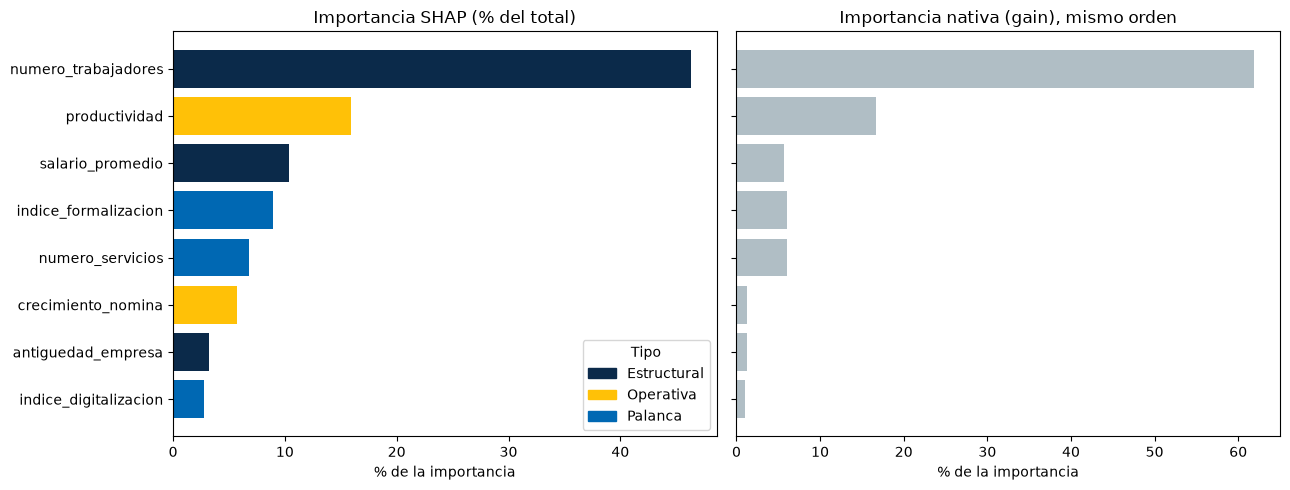

In [18]:
cols_expl = cols_ga
modelo_expl = clonar(modelo_ganador).fit(X_tr[cols_expl], y_tr)
pred_expl_log = modelo_expl.predict(X_te[cols_expl])
pred_expl = np.exp(pred_expl_log)
mae_expl = metricas_cop(y_te, pred_expl_log)["mae"]
print(f"Modelo que se explica: {ganador} con {len(cols_expl)} variables (parsimonioso). Error en el examen final: {mae_expl:,.0f} COP "
      f"frente a {ho['mae']:,.0f} COP del modelo completo ({mae_expl / ho['mae'] - 1:+.1%}).")
from sklearn.metrics import r2_score
r2_expl_cop, r2_expl_log = r2_score(np.exp(y_te), pred_expl), r2_score(y_te, pred_expl_log)
print(f"R² del modelo parsimonioso: {r2_expl_cop:.1%} en pesos | {r2_expl_log:.1%} en escala log "
      f"(modelo completo: {r2_score(np.exp(y_te), np.exp(final.predict(X_te[cols_final]))):.1%} | {r2_score(y_te, final.predict(X_te[cols_final])):.1%}).")
grupos_modelo = {g: grupos[g] for g in genes_ga}
sv, imp_gen, base, err_adit = shap_arboles(modelo_expl, X_te[cols_expl], grupos_modelo)
print(f"Aditividad SHAP: error máximo |base + suma(SHAP) - predicción| = {err_adit:.2e} (escala log)  -> {'cumple' if err_adit < 1e-4 else 'REVISAR'} (< 1e-4)")
pct = (imp_gen / imp_gen.sum() * 100).round(1)

TIPO = {  # SUPUESTO de negocio (criterio del analista), no derivado de los datos
    "numero_trabajadores": "Estructural", "salario_promedio": "Estructural", "antiguedad_empresa": "Estructural",
    "distancia_centro": "Estructural", "indice_competencia": "Estructural", "ciudad": "Estructural", "sector": "Estructural",
    "productividad": "Operativa", "crecimiento_nomina": "Operativa", "rotacion_personal": "Operativa",
    "indice_formalizacion": "Palanca", "indice_digitalizacion": "Palanca", "numero_servicios": "Palanca", "satisfaccion_servicio": "Palanca"}
COLOR_TIPO = {"Estructural": "#0B2A4A", "Operativa": "#FFC107", "Palanca": "#0068B3"}

gain_col = pd.Series(modelo_expl.feature_importances_.astype(float), index=cols_expl)
gain_gen = pd.Series({g: gain_col[[c for c in grupos[g] if c in gain_col.index]].sum() for g in grupos_modelo})
tabla_imp = pd.DataFrame({"Tipo": pd.Series(TIPO), "SHAP (%)": pct, "Gain nativo (%)": (gain_gen / gain_gen.sum() * 100).round(1)}).loc[pct.index]
print("\nRanking de importancia (mayor a menor). SHAP = peso medio de la variable en la predicción; Gain = importancia nativa del árbol:")
print(tabla_imp.to_string())
print("\nPeso total por tipo de variable (SHAP, %):")
print(tabla_imp.groupby("Tipo")["SHAP (%)"].sum().sort_values(ascending=False).round(1).to_string())
print("\nTipos: Estructural = tamaño y contexto de la empresa | Operativa = desempeño interno | Palanca = lo que Colsubsidio puede gestionar con la empresa (supuesto de negocio).")

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
orden = tabla_imp.index[::-1]
ax[0].barh(orden, tabla_imp.loc[orden, "SHAP (%)"], color=[COLOR_TIPO[TIPO[g]] for g in orden])
ax[0].set_title("Importancia SHAP (% del total)"); ax[0].set_xlabel("% de la importancia")
ax[1].barh(orden, tabla_imp.loc[orden, "Gain nativo (%)"], color="#B0BEC5")
ax[1].set_title("Importancia nativa (gain), mismo orden"); ax[1].set_xlabel("% de la importancia")
ax[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR_TIPO.values()], labels=list(COLOR_TIPO), loc="lower right", title="Tipo")
plt.tight_layout(); plt.show()

# FASE 5b — INTERPRETABILIDAD (2/3): EFECTO DE CADA VARIABLE EN PESOS (COP)
#### - Se traduce la contribución SHAP de cada variable a pesos de aporte: efecto = predicción x (1 - exp(-SHAP)), porque el modelo trabaja en log.
#### - Cada punto de un gráfico es una empresa del examen final; la línea roja es el promedio por tramo de la variable.
#### - La recta ajustada resume el efecto promedio por unidad; su R² indica qué tan lineal es el efecto (cerca de 1 = casi lineal).

Efecto promedio en el aporte por cada unidad adicional de la variable (hold-out, asociación del modelo):
  numero_trabajadores      [Estructural]     +166,932 COP por trabajador adicional  (R² de la recta: 0.97)
  productividad            [Operativa  ]      +84,640 COP por punto más de productividad  (R² de la recta: 0.92)
  salario_promedio         [Estructural]     +848,446 COP por millón de COP más de salario promedio  (R² de la recta: 0.66)
  indice_formalizacion     [Palanca    ]      +61,819 COP por punto más de formalización  (R² de la recta: 0.92)
  numero_servicios         [Palanca    ]     +406,873 COP por servicio adicional  (R² de la recta: 0.81)
  crecimiento_nomina       [Operativa  ]      +53,724 COP por punto más de crecimiento de nómina  (R² de la recta: 0.85)
  antiguedad_empresa       [Estructural]      +20,595 COP por año más de antigüedad  (R² de la recta: 0.82)
  indice_digitalizacion    [Palanca    ]      +17,321 COP por punto más de digitalización  (R² de la rec

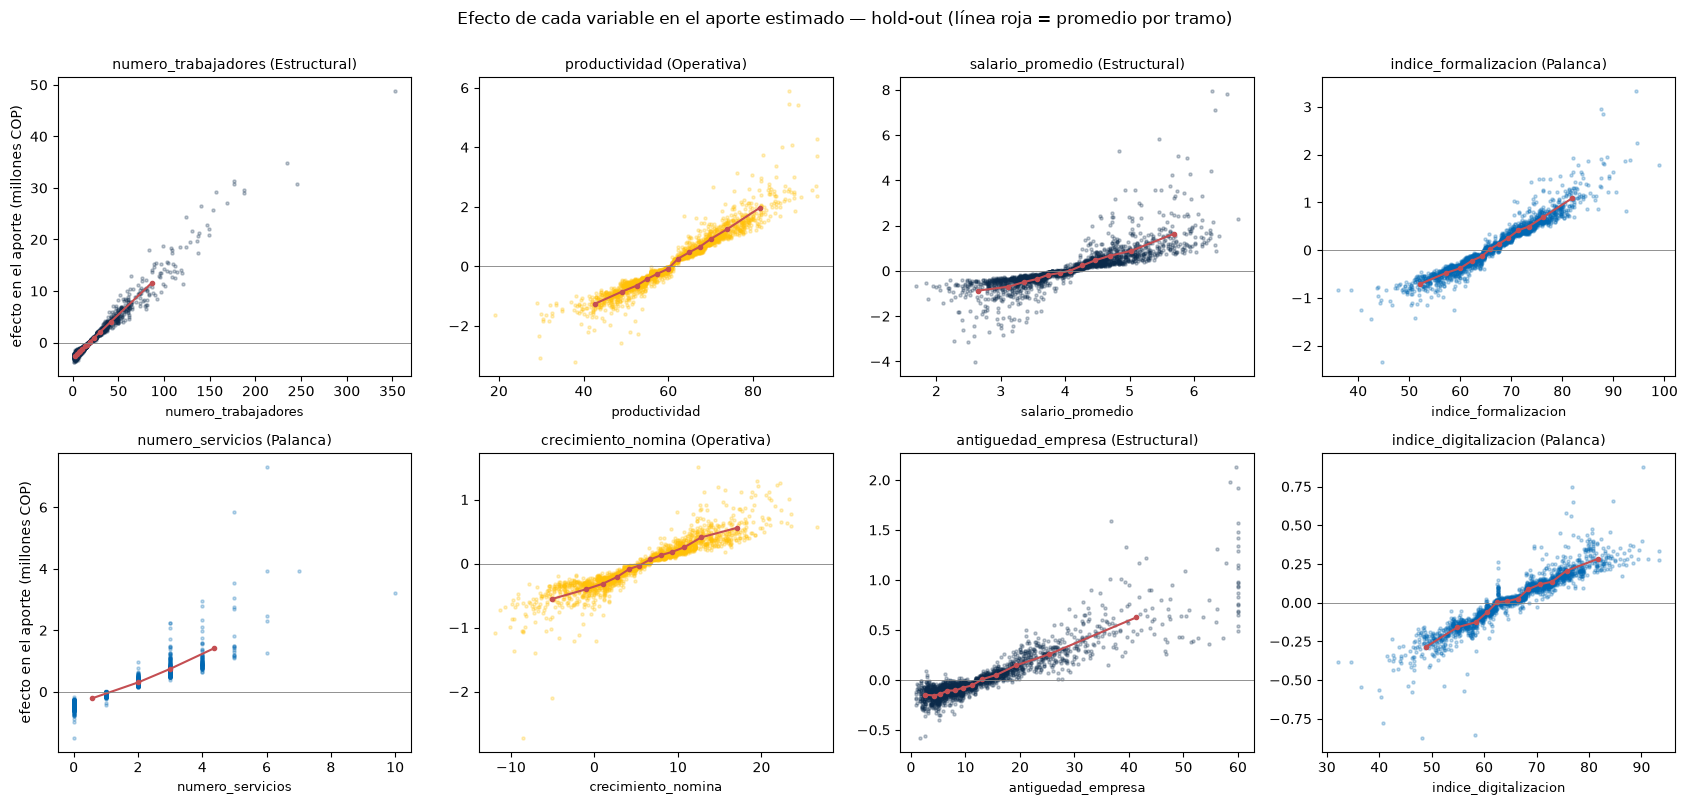

In [19]:
cols_te = list(X_te[cols_expl].columns)
shap_gen = pd.DataFrame({g: sv[:, [cols_te.index(c) for c in grupos[g] if c in cols_te]].sum(axis=1) for g in grupos_modelo})
efecto_cop = pd.DataFrame({g: pred_expl * (1 - np.exp(-shap_gen[g].to_numpy())) for g in shap_gen})   # pred_expl: predicción del modelo parsimonioso (celda 10)

UNIDAD = {"numero_trabajadores": "trabajador adicional", "salario_promedio": "millón de COP más de salario promedio",
          "productividad": "punto más de productividad", "indice_formalizacion": "punto más de formalización",
          "numero_servicios": "servicio adicional", "crecimiento_nomina": "punto más de crecimiento de nómina",
          "indice_digitalizacion": "punto más de digitalización", "antiguedad_empresa": "año más de antigüedad",
          "rotacion_personal": "punto más de rotación", "satisfaccion_servicio": "punto más de satisfacción",
          "distancia_centro": "unidad más de distancia al centro", "indice_competencia": "punto más de competencia"}
numericas = [g for g in imp_gen.index if g not in ("ciudad", "sector")][:8]
filas = []
for g in numericas:
    x, e = X_te[g].to_numpy(dtype=float), efecto_cop[g].to_numpy()
    pendiente, intercepto = np.polyfit(x, e, 1)
    r2 = 1 - np.sum((e - (pendiente * x + intercepto)) ** 2) / np.sum((e - e.mean()) ** 2)
    filas.append(dict(variable=g, tipo=TIPO[g], efecto_por_unidad_cop=pendiente, r2_recta=r2, unidad=UNIDAD.get(g, "unidad")))
efectos = pd.DataFrame(filas).set_index("variable")
print("Efecto promedio en el aporte por cada unidad adicional de la variable (hold-out, asociación del modelo):")
for g, f in efectos.iterrows():
    print(f"  {g:<24} [{f['tipo']:<11}] {f['efecto_por_unidad_cop']:>+12,.0f} COP por {f['unidad']}  (R² de la recta: {f['r2_recta']:.2f})")
presentes = [g for g in ("sector", "ciudad") if g in pct.index]
if presentes:
    print("\nPeso de sector y ciudad: " + ", ".join(f"{g} {pct[g]}%" for g in presentes) + " (aportan muy poco a la predicción una vez consideradas las demás variables).")
else:
    print("\nsector y ciudad no entran en el modelo parsimonioso: el algoritmo genético las descartó porque no aportan una vez conocidas las demás variables.")

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, g in zip(axes.flatten(), numericas):
    x, e = X_te[g].to_numpy(dtype=float), efecto_cop[g].to_numpy() / 1e6
    ax.scatter(x, e, s=5, alpha=0.25, color=COLOR_TIPO[TIPO[g]])
    tramo = pd.qcut(pd.Series(x), 12, duplicates="drop")
    medias = pd.DataFrame({"x": x, "e": e}).groupby(tramo, observed=True).mean()
    ax.plot(medias["x"], medias["e"], color="#C44E52", marker="o", markersize=3, linewidth=1.5)
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.set_title(f"{g} ({TIPO[g]})", fontsize=10); ax.set_xlabel(g, fontsize=9)
    ax.set_ylabel("efecto en el aporte (millones COP)" if g == numericas[0] or g == numericas[4] else "")
plt.suptitle("Efecto de cada variable en el aporte estimado — hold-out (línea roja = promedio por tramo)", y=1.0)
plt.tight_layout(); plt.show()


# RESPUESTA: ¿QUÉ SE ASOCIA CON EL APORTE MENSUAL?

#### 1. Frente estructural (tamaño y contexto): explica el 59.9% de la importancia.
#### - numero_trabajadores (46.3%): +166,932 COP por trabajador adicional.
#### - salario_promedio (10.4%): +848,446 COP por millón de COP más de salario promedio.
#### - antiguedad_empresa (3.2%): +20,595 COP por año más de antigüedad.

<br>

#### 2. Frente operativo (desempeño interno): el 21.6%.
#### - productividad (15.9%): +84,640 COP por punto más de productividad.
#### - crecimiento_nomina (5.7%): +53,724 COP por punto más de crecimiento de nómina.

<br>

#### 3. Palancas que Colsubsidio puede gestionar con la empresa: el 18.5%.
#### - indice_formalizacion (8.9%): +61,819 COP por punto más de formalización (+10 puntos: +618,193 COP).
#### - numero_servicios (6.8%): +406,873 COP por servicio adicional.
#### - indice_digitalizacion (2.8%): +17,321 COP por punto más de digitalización (+10 puntos: +173,213 COP).

<br>

#### CONCLUSIÓN ACCIONABLE
#### - El tamaño de la empresa es lo que más se asocia con el aporte (numero_trabajadores: 46.3%); las palancas de gestión pesan, en conjunto, 18.5%.
#### - Las palancas con efecto medido son hipótesis de trabajo: conviene probarlas con un piloto antes de prometer un aporte mayor a una empresa.
#### - LIMITACIÓN: son asociaciones del modelo en datos observacionales; la clasificación por tipo es un supuesto de negocio; los efectos por unidad son promedios.
#### - NOTA: esta interpretación explica el modelo parsimonioso de 8 variables (error 448,002 COP); la predicción oficial usa el modelo completo (432,254 COP).

# RESULTADOS PRINCIPALES
#### 1. Datos: 10,000 empresas, 0 nulos y 0 duplicados; los atípicos se conservan (corresponden a empresas grandes).
#### 2. Modelos: se compararon 6 (2 referencias simples y 4 de aprendizaje automático). Gana XGBoost(log) con un error de validación de 429,261 COP, 84% menos que la estimación simple por sector (2,722,856 COP).
#### 3. Escala del objetivo: con XGBoost(log), entrenar sobre el aporte directo rinde 3.4% mejor que sobre el log (gana en 5 de 5 folds); se mantiene el log por interpretabilidad.
#### 4. Examen final (2,000 empresas nuevas, modelo completo): error típico 432,254 COP (4.1% del aporte medio), MAPE 3.81%, R² 96.3%; el total de la cartera queda -0.49% frente al real.
#### 5. Rango esperado (80 %): predicción x0.950 a x1.053; el aporte real cayó dentro del rango en el 79.7% de las empresas.
#### 6. Parsimonia: el algoritmo genético deja 8 de 14 variables originales de forma estable (8 de 33 columnas), las cuales son :  
#### numero_trabajadores (46.3%), productividad (15.9%), salario_promedio (10.4%) de la importancia total. Por tipo: Estructural 59.9%, Operativa 21.6%, Palanca 18.5%.
####    - Palanca indice_formalizacion (8.9%): +61,819 COP por punto más de formalización (asociación).
####    - Palanca indice_digitalizacion (2.8%): +17,321 COP por punto más de digitalización (asociación).
####    - Palanca numero_servicios (6.8%): +406,873 COP por servicio adicional (asociación).

# RECOMENDACIONES
#### - Usar la predicción como referencia del aporte esperado y el rango (x0.95 a x1.05) como rango de negociación y alerta de aportes atípicos.
#### - Priorizar el seguimiento comercial según el tamaño de la empresa (numero_trabajadores, la variable más asociada con el aporte).
#### - Tratar indice_formalizacion, indice_digitalizacion, numero_servicios como hipótesis de piloto: probar con un grupo de empresas antes de prometer un aporte mayor.
